# YOLOv1 + SVP Pruning Pipeline

Notebook tích hợp **SVP (Singular Value Pruning)** từ `SVP-main` vào pipeline YOLOv1 của repo này.

**Quy trình 4 bước:**
1. Train **dense** model
2. **SVP-GAM** prune + surgery → `model_lean.pth`
3. **Finetune** lean model
4. **Benchmark** dense vs pruned

So với `prune.py` (bi-level Song Han + L1-inf-inf), `prune_svp.py` dùng thuật toán **GAM** (Greedy Addition Method) dựa trên singular values — giống `SVP-main/pruning_rate.py`.

> Điền `REPO_ROOT` trong cell **Cấu hình** bên dưới trước khi chạy.

## ⚙️ Cấu hình (điền thông số tại đây)

Các biến dưới đây tương ứng với `scripts/run_e2e.sh`. Chỉnh trực tiếp rồi chạy các cell bên dưới.

In [1]:
# ===================== CONFIG (env-overridable style) =====================
REPO_ROOT   = r"/kaggle/input/datasets/chvminh/code-onestage/OnestageDetectionPunner"   # root project — điền đường dẫn repo của bạn

DATA        = "/kaggle/input/datasets/chvminh/deepfish/NewDeepfish"          # đường dẫn dataset (images/ + labels/)
BACKBONE    = "resnet18"               # resnet18/34/50/101, vgg16/19
NUM_CLASSES = 1                        # số class (auto-detect nếu = -1)
INPUT       = 448                      # kích thước ảnh đầu vào
BATCH       = 32
WORKERS     = 8
DEVICE      = "auto"                     # auto | cpu | cuda

OUT         = f"/kaggle/working/output/yolo_svp_{BACKBONE}"   # thư mục output

# --- Pruning (SVP) ---
TARGET_RATE     = 0.5                  # SVP compress rate (0.5 = cắt ~50% kênh)
FINETUNE_EPOCHS = 5                    # finetune sau khi SVP prune (step 2)
SCOPE           = "all"                  # all | backbone | neck

DENSE_EPOCHS = 5                      # epoch train dense (step 1)
FINAL_EPOCHS = 5                      # epoch finetune lean (step 3)

WANDB       = False                    # True -> bật Weights & Biases
PRETRAINED  = True                     # True -> ImageNet pretrained backbone (step 1)

# --- Tùy chọn ---
SKIP_STEP1  = False                    # True nếu đã có checkpoint dense
SKIP_STEP2  = False
SKIP_STEP3  = False
SKIP_STEP4  = False
# =========================================================================

In [2]:
import os
import sys
import subprocess
from pathlib import Path

# Dùng REPO_ROOT từ cell CONFIG ở trên
REPO_ROOT = Path(REPO_ROOT).resolve()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

PY = sys.executable
print(f"Repo root: {REPO_ROOT}")
print(f"Python:    {PY}")
print(f"Output:    {OUT}")

Repo root: /kaggle/input/datasets/chvminh/code-onestage/OnestageDetectionPunner
Python:    /usr/bin/python3
Output:    /kaggle/working/output/yolo_svp_resnet18


## Step 1/4 — Train DENSE model

In [3]:
step1_dir = os.path.join(OUT, "step1_dense")
step1_ckpt = os.path.join(step1_dir, "model_best.pth")

if SKIP_STEP1 and os.path.isfile(step1_ckpt):
    print(f"[SKIP] Step 1 — đã có checkpoint: {step1_ckpt}")
else:
    cmd = [
        PY, "train.py",
        "--data-path", DATA,
        "--backbone", BACKBONE,
        "--input-size", str(INPUT),
        "--epochs", str(DENSE_EPOCHS),
        "--batch-size", str(BATCH),
        "--workers", str(WORKERS),
        "--device", DEVICE,
        "--output-dir", step1_dir,
        "--augment",
    ]
    if NUM_CLASSES > 0:
        cmd += ["--num-classes", str(NUM_CLASSES)]
    if PRETRAINED:
        cmd.append("--pretrained-backbone")
    if WANDB:
        cmd.append("--wandb")

    print(" ".join(cmd))
    subprocess.run(cmd, check=True)
    print(f"\nDone Step 1 -> {step1_ckpt}")

/usr/bin/python3 train.py --data-path /kaggle/input/datasets/chvminh/deepfish/NewDeepfish --backbone resnet18 --input-size 448 --epochs 5 --batch-size 32 --workers 8 --device auto --output-dir /kaggle/working/output/yolo_svp_resnet18/step1_dense --augment --num-classes 1 --pretrained-backbone


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Device: cuda
[YoloDataset:train] 3596 images in /kaggle/input/datasets/chvminh/deepfish/NewDeepfish/images/train (letterbox=True, normalize=True)
[YoloDataset:val] 909 images in /kaggle/input/datasets/chvminh/deepfish/NewDeepfish/images/val (letterbox=True, normalize=True)
[pretrained] resnet18: loaded 120 tensors, forward-verify OK (max diff=0.00e+00)
Model resnet18 | params=21.93M | grid=14
  [E1/5    0/113] loss=31.3986 obj=0.7242 noobj=48.1977 box=1.3151 cls=0.0000
  [E1/5   50/113] loss=2.9554 obj=0.2083 noobj=0.0000 box=0.5494 cls=0.0000
  [E1/5  100/113] loss=2.1486 obj=0.3953 noobj=0.0000 box=0.3507 cls=0.0000
  -> epoch 1 train: loss=4.1618 obj=0.2292 noobj=2.6314 box=0.5234 cls=0.0000  (64.9s)
  -> val: loss=1.9560 obj=0.2981 noobj=0.0000 box=0.3316 cls=0.0000
  -> val mAP@0.5=0.0003 mAP@0.9=0.0000 mAP@0.5:0.95=0.0001
  ** new best (mAP@0.5:0.95=0.0001) -> model_best.pth
  [E2/5    0/113] loss=2.8984 obj=0.4040 noobj=0.0000 box=0.4989 cls=0.0000
  [E2/5   50/113] loss=1.5866 

## Step 2/4 — SVP-GAM Prune + Surgery

Dùng `prune_svp.py` (logic port từ `SVP-main/pruning_rate.py`).

In [4]:
step2_dir = os.path.join(OUT, "step2_svp")
lean_ckpt = os.path.join(step2_dir, "model_lean.pth")

if SKIP_STEP2 and os.path.isfile(lean_ckpt):
    print(f"[SKIP] Step 2 — đã có lean model: {lean_ckpt}")
else:
    cmd = [
        PY, "prune_svp.py",
        "--data-path", DATA,
        "--checkpoint", step1_ckpt,
        "--target-rate", str(TARGET_RATE),
        "--finetune-epochs", str(FINETUNE_EPOCHS),
        "--scope", SCOPE,
        "--batch-size", str(BATCH),
        "--workers", str(WORKERS),
        "--device", DEVICE,
        "--output-dir", step2_dir,
    ]
    print(" ".join(cmd))
    subprocess.run(cmd, check=True)
    print(f"\nDone Step 2 -> {lean_ckpt}")

/usr/bin/python3 prune_svp.py --data-path /kaggle/input/datasets/chvminh/deepfish/NewDeepfish --checkpoint /kaggle/working/output/yolo_svp_resnet18/step1_dense/model_best.pth --target-rate 0.5 --finetune-epochs 5 --scope all --batch-size 32 --workers 8 --device auto --output-dir /kaggle/working/output/yolo_svp_resnet18/step2_svp


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Device: cuda
Loaded dense resnet18 | input=448 | classes=1
[YoloDataset:train] 3596 images in /kaggle/input/datasets/chvminh/deepfish/NewDeepfish/images/train (letterbox=True, normalize=True)
[YoloDataset:val] 909 images in /kaggle/input/datasets/chvminh/deepfish/NewDeepfish/images/val (letterbox=True, normalize=True)

Baseline params=21.93M | scope=all | method=SVP-GAM
  -> val: loss=1.4482 obj=0.6239 noobj=0.0000 box=0.1648 cls=0.0000
  [baseline] mAP@0.5=0.0009  mAP@0.5:0.95=0.0003

=== SVP-GAM prune | target_rate=0.500 ===
[SVP-GAM] target_rate=0.500 -> kept 2752/5504 filters (50.0%) across 13 layers.
  compress_rate per layer (first 10): [0.312, 0.188, 0.336, 0.102, 0.43, 0.168, 0.42, 0.092, 0.639, 0.624]...

=== Finetune 5 epoch(s) ===
  [E1/5    0/113] loss=3.1314 obj=0.1532 noobj=0.0007 box=0.5956 cls=0.0000
  [E1/5   50/113] loss=1.7086 obj=0.3964 noobj=0.0011 box=0.2623 cls=0.0000
  [E1/5  100/113] loss=1.6581 obj=0.5199 noobj=0.0010 box=0.2275 cls=0.0000
  -> epoch 1 train: 

### (Tùy chọn) Xem phân bổ kênh SVP-GAM trực tiếp trong notebook

In [5]:
import torch
from models.yolo import build_model
from pruning.svp import SVPPruner

try:
    ckpt = torch.load(step1_ckpt, map_location="cpu", weights_only=False)
except TypeError:
    ckpt = torch.load(step1_ckpt, map_location="cpu")

model = build_model(ckpt["config"])
model.load_state_dict(ckpt["model"])

class Scope:
    def __init__(self, m, which="all"):
        self.model = m
        self.which = which
    def get_prunable_layers(self, pruning_type="structured"):
        if self.which == "backbone":
            return self.model.get_backbone_prunable_layers(pruning_type)
        if self.which == "neck":
            return self.model.get_neck_prunable_layers(pruning_type)
        return self.model.get_prunable_layers(pruning_type)

svp = SVPPruner(Scope(model, SCOPE))
layers, keep, rates = svp.compute_allocation(TARGET_RATE)

print(f"Scope={SCOPE} | target_rate={TARGET_RATE} | {len(layers)} layers")
print(f"{'Layer':>6} {'Orig':>6} {'Keep':>6} {'Rate':>8}")
print("-" * 30)
for i, (k, r) in enumerate(zip(keep, rates)):
    orig = layers[i].conv.out_channels
    print(f"{i:>6} {orig:>6} {k:>6} {r:>8.3f}")

Scope=all | target_rate=0.5 | 13 layers
 Layer   Orig   Keep     Rate
------------------------------
     0     64     44    0.312
     1     64     52    0.188
     2    128     85    0.336
     3    128    115    0.102
     4    256    146    0.430
     5    256    213    0.168
     6    512    298    0.418
     7    512    465    0.092
     8    512    185    0.639
     9   1024    385    0.624
    10    512    191    0.627
    11   1024    382    0.627
    12    512    191    0.627


## Step 3/4 — Finetune LEAN model

In [6]:
step3_dir = os.path.join(OUT, "step3_final")
final_ckpt = os.path.join(step3_dir, "model_best.pth")
lean_json = lean_ckpt.replace(".pth", ".json")

if SKIP_STEP3 and os.path.isfile(final_ckpt):
    print(f"[SKIP] Step 3 — đã có final model: {final_ckpt}")
else:
    cmd = [
        PY, "train.py",
        "--data-path", DATA,
        "--input-size", str(INPUT),
        "--epochs", str(FINAL_EPOCHS),
        "--batch-size", str(BATCH),
        "--workers", str(WORKERS),
        "--device", DEVICE,
        "--init-config", lean_json,
        "--weights", lean_ckpt,
        "--output-dir", step3_dir,
        "--augment",
    ]
    if NUM_CLASSES > 0:
        cmd += ["--num-classes", str(NUM_CLASSES)]
    if WANDB:
        cmd.append("--wandb")

    print(" ".join(cmd))
    subprocess.run(cmd, check=True)
    print(f"\nDone Step 3 -> {final_ckpt}")

/usr/bin/python3 train.py --data-path /kaggle/input/datasets/chvminh/deepfish/NewDeepfish --input-size 448 --epochs 5 --batch-size 32 --workers 8 --device auto --init-config /kaggle/working/output/yolo_svp_resnet18/step2_svp/model_lean.json --weights /kaggle/working/output/yolo_svp_resnet18/step2_svp/model_lean.pth --output-dir /kaggle/working/output/yolo_svp_resnet18/step3_final --augment --num-classes 1


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Device: cuda
[YoloDataset:train] 3596 images in /kaggle/input/datasets/chvminh/deepfish/NewDeepfish/images/train (letterbox=True, normalize=True)
[YoloDataset:val] 909 images in /kaggle/input/datasets/chvminh/deepfish/NewDeepfish/images/val (letterbox=True, normalize=True)
[Step 3] Lean model from /kaggle/working/output/yolo_svp_resnet18/step2_svp/model_lean.json
Loaded weights /kaggle/working/output/yolo_svp_resnet18/step2_svp/model_lean.pth (missing=0, unexpected=0)
Model resnet18 | params=10.08M | grid=14
  [E1/5    0/113] loss=1.2289 obj=0.7742 noobj=0.0207 box=0.0889 cls=0.0000
  [E1/5   50/113] loss=1.5274 obj=0.4983 noobj=0.0525 box=0.2006 cls=0.0000
  [E1/5  100/113] loss=1.0164 obj=0.3756 noobj=0.1330 box=0.1149 cls=0.0000
  -> epoch 1 train: loss=1.2546 obj=0.5269 noobj=0.0551 box=0.1400 cls=0.0000  (64.7s)
  -> val: loss=1.1879 obj=0.3486 noobj=0.1046 box=0.1574 cls=0.0000
  -> val mAP@0.5=0.0961 mAP@0.9=0.0000 mAP@0.5:0.95=0.0227
  ** new best (mAP@0.5:0.95=0.0227) -> model

## Step 4/4 — Benchmark DENSE vs PRUNED

In [7]:
if SKIP_STEP4:
    print("[SKIP] Step 4")
else:
    cmd = [
        PY, "benchmark.py",
        "--dense", step1_ckpt,
        "--pruned", final_ckpt,
        "--data-path", DATA,
        "--batch-size", str(BATCH),
        "--workers", str(WORKERS),
        "--device", DEVICE,
    ]
    if NUM_CLASSES > 0:
        cmd += ["--num-classes", str(NUM_CLASSES)]

    print(" ".join(cmd))
    subprocess.run(cmd, check=True)
    print("\nPipeline SVP hoàn tất!")

/usr/bin/python3 benchmark.py --dense /kaggle/working/output/yolo_svp_resnet18/step1_dense/model_best.pth --pruned /kaggle/working/output/yolo_svp_resnet18/step3_final/model_best.pth --data-path /kaggle/input/datasets/chvminh/deepfish/NewDeepfish --batch-size 32 --workers 8 --device auto --num-classes 1


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Device: cuda

Measuring DENSE...
  [thop] skip FLOPs (No module named 'thop')
Measuring PRUNED...
  [thop] skip FLOPs (No module named 'thop')
[YoloDataset:val] 909 images in /kaggle/input/datasets/chvminh/deepfish/NewDeepfish/images/val (letterbox=True, normalize=True)

mAP DENSE...
mAP PRUNED...

Metric             |          Dense |         Pruned |          Delta
------------------------------------------------------------------------
Params (M)         |          21.93 |          10.08 |         -54.0%
Latency (ms)       |           6.81 |           4.21 |         -38.2%
FPS                |         146.79 |         237.70 |         +61.9%
mAP@0.5            |         0.0009 |         0.3026 |        +0.3017
mAP@0.5:0.95       |         0.0003 |         0.0926 |        +0.0923

Pipeline SVP hoàn tất!


## Kết quả so sánh Dense vs Pruned

Bảng và biểu đồ dưới đây chạy trực tiếp trong notebook (không cần đọc log terminal).

Loading models...
Measuring efficiency...
  [thop] skip FLOPs (No module named 'thop')
  [thop] skip FLOPs (No module named 'thop')
[YoloDataset:val] 909 images in /kaggle/input/datasets/chvminh/deepfish/NewDeepfish/images/val (letterbox=True, normalize=True)
Evaluating mAP...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Metric,Dense,Pruned,Delta
Params (M),21.930000,10.080000,-54.0%
Latency (ms),6.930000,4.230000,-39.0%
FPS,144.220000,236.510000,+64.0%
mAP@0.5,0.000900,0.302600,+0.3017
mAP@0.5:0.95,0.000300,0.092600,+0.0923


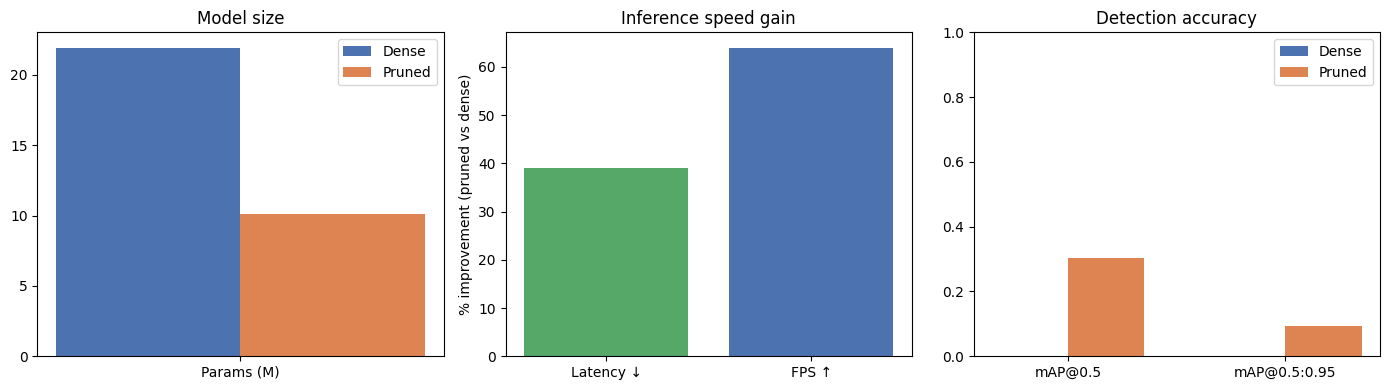


Params reduction : 54.0%
Speed-up (FPS)   : +64.0%
mAP@0.5 change   : +0.3017


In [8]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from benchmark import load_model, measure_efficiency, resolve_device
from data import YoloDataset
from utils import evaluate_map

device = resolve_device(DEVICE)
input_size = INPUT

print("Loading models...")
dense_model, dcfg = load_model(step1_ckpt)
pruned_model, pcfg = load_model(final_ckpt)

print("Measuring efficiency...")
p_dense, f_dense, lat_dense, fps_dense = measure_efficiency(dense_model, input_size, device)
p_pruned, f_pruned, lat_pruned, fps_pruned = measure_efficiency(pruned_model, input_size, device)

nc = NUM_CLASSES if NUM_CLASSES > 0 else dcfg.get("num_classes", 1)
val_ds = YoloDataset(DATA, "val", input_size, augment=False)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=BATCH, shuffle=False, num_workers=WORKERS,
    collate_fn=YoloDataset.collate_fn)

print("Evaluating mAP...")
map_dense = evaluate_map(dense_model, val_loader, device, nc)
map_pruned = evaluate_map(pruned_model, val_loader, device, nc)

def delta_pct(a, b):
    return (1 - b / a) * 100 if a else 0.0

rows = [
    {
        "Metric": "Params (M)",
        "Dense": round(p_dense / 1e6, 2),
        "Pruned": round(p_pruned / 1e6, 2),
        "Delta": f"-{delta_pct(p_dense, p_pruned):.1f}%",
    },
    {
        "Metric": "Latency (ms)",
        "Dense": round(lat_dense, 2),
        "Pruned": round(lat_pruned, 2),
        "Delta": f"-{delta_pct(lat_dense, lat_pruned):.1f}%",
    },
    {
        "Metric": "FPS",
        "Dense": round(fps_dense, 2),
        "Pruned": round(fps_pruned, 2),
        "Delta": f"+{(fps_pruned / fps_dense - 1) * 100:.1f}%",
    },
    {
        "Metric": "mAP@0.5",
        "Dense": round(map_dense["mAP@0.5"], 4),
        "Pruned": round(map_pruned["mAP@0.5"], 4),
        "Delta": f"{map_pruned['mAP@0.5'] - map_dense['mAP@0.5']:+.4f}",
    },
    {
        "Metric": "mAP@0.5:0.95",
        "Dense": round(map_dense["mAP@0.5:0.95"], 4),
        "Pruned": round(map_pruned["mAP@0.5:0.95"], 4),
        "Delta": f"{map_pruned['mAP@0.5:0.95'] - map_dense['mAP@0.5:0.95']:+.4f}",
    },
]
if f_dense and f_pruned:
    rows.insert(1, {
        "Metric": "FLOPs (G)",
        "Dense": round(f_dense / 1e9, 2),
        "Pruned": round(f_pruned / 1e9, 2),
        "Delta": f"-{delta_pct(f_dense, f_pruned):.1f}%",
    })

df = pd.DataFrame(rows)
display(df.style.hide(axis="index").set_caption(
    f"SVP prune | backbone={BACKBONE} | target_rate={TARGET_RATE} | scope={SCOPE}"
))

# --- Biểu đồ ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Params & FLOPs
eff_metrics, eff_dense, eff_pruned = ["Params (M)"], [p_dense / 1e6], [p_pruned / 1e6]
if f_dense and f_pruned:
    eff_metrics.append("FLOPs (G)")
    eff_dense.append(f_dense / 1e9)
    eff_pruned.append(f_pruned / 1e9)
x = range(len(eff_metrics))
w = 0.35
axes[0].bar([i - w/2 for i in x], eff_dense, width=w, label="Dense", color="#4C72B0")
axes[0].bar([i + w/2 for i in x], eff_pruned, width=w, label="Pruned", color="#DD8452")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(eff_metrics)
axes[0].set_title("Model size")
axes[0].legend()

# Speed (hiển thị % cải thiện thay vì gộp 2 thang đo khác nhau)
speed_labels = ["Latency ↓", "FPS ↑"]
speed_gain = [delta_pct(lat_dense, lat_pruned), (fps_pruned / fps_dense - 1) * 100]
axes[1].bar(speed_labels, speed_gain, color=["#55A868", "#4C72B0"])
axes[1].set_ylabel("% improvement (pruned vs dense)")
axes[1].set_title("Inference speed gain")

# mAP
map_labels = ["mAP@0.5", "mAP@0.5:0.95"]
map_d = [map_dense["mAP@0.5"], map_dense["mAP@0.5:0.95"]]
map_p = [map_pruned["mAP@0.5"], map_pruned["mAP@0.5:0.95"]]
x2 = range(2)
axes[2].bar([i - w/2 for i in x2], map_d, width=w, label="Dense", color="#4C72B0")
axes[2].bar([i + w/2 for i in x2], map_p, width=w, label="Pruned", color="#DD8452")
axes[2].set_xticks(list(x2))
axes[2].set_xticklabels(map_labels)
axes[2].set_ylim(0, 1)
axes[2].set_title("Detection accuracy")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nParams reduction : {delta_pct(p_dense, p_pruned):.1f}%")
if f_dense and f_pruned:
    print(f"FLOPs reduction  : {delta_pct(f_dense, f_pruned):.1f}%")
print(f"Speed-up (FPS)   : +{(fps_pruned / fps_dense - 1) * 100:.1f}%")
print(f"mAP@0.5 change   : {map_pruned['mAP@0.5'] - map_dense['mAP@0.5']:+.4f}")